Loaded with encoding: gb18030

▶ Stage counts:
P5    52309
P4    44226
P1    20402
P3    19014
P2    13166
Name: Stage, dtype: int64

▶ ROI list per stage (n):
Stage
P1    4
P2    5
P3    8
P4    4
P5    9
Name: ROI, dtype: int64


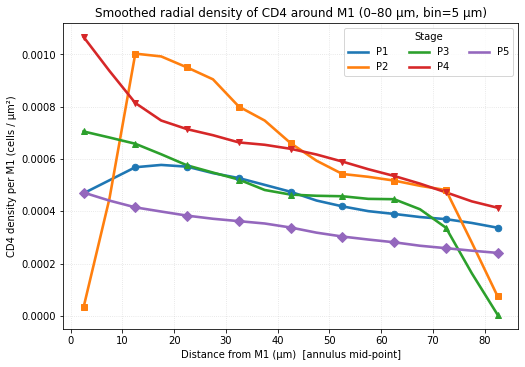

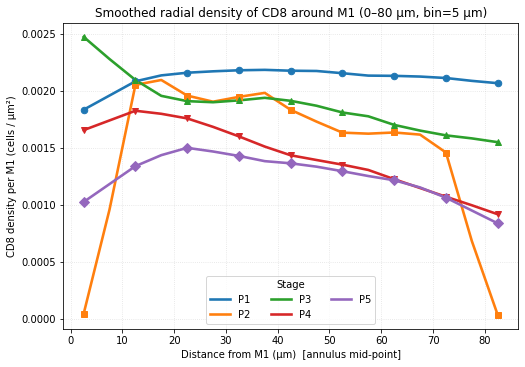


DONE.


In [1]:
# -*- coding: utf-8 -*-
# 从原始 annotated_cells_mixed.csv 开始：
# 计算 M1 周围 0–80µm 的 ring-shell 径向密度（cells/µm^2），并用 LOWESS 平滑
# 输出：CD4 五期五条曲线一张图；CD8 五期五条曲线一张图（带实心点）

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from statsmodels.nonparametric.smoothers_lowess import lowess

# ====================== 参数区（只改这里） ======================
file_path = r"C:/Users/Li Chujia/Desktop/cell_annotationV2/annotated_cells_mixed.csv"
ENCODING = "gbk"

MAX_R = 80.0       # 最大半径（µm）
BIN = 5.0          # 环带宽度（µm）
EPS = 1e-12

LOWESS_FRAC = 0.35  # 越大越平滑：0.25~0.50

# 每隔几个bin标一个点（2或3都行）
MARK_EVERY_BINS = 2

# stage 映射：Txxx -> P1..P5
stage_labels = {"T005":"P1","T006":"P2","T001":"P3","T002":"P4","T004":"P5"}
stage_codes  = ["T005","T006","T001","T002","T004"]
stage_order  = ["P1","P2","P3","P4","P5"]

# 列名（按你文件）
COL_ROI  = "ROI"
COL_X    = "X_position"
COL_Y    = "Y_position"
COL_TYPE = "cell_type"

# cell_type 名称
M1_NAME  = "M1"
CD4_NAME = "CD4_T"
CD8_NAME = "CD8_T"

# ====== 可选：按你指定 ROI 白名单过滤（需要就取消注释）======
# roi_whitelist = {
#     "T001": {"001", "003", "007"},
#     "T002": {"021", "023"},
#     "T006": {"001", "003"},
#     "T004": {"008", "010"},
#     "T005": {"001", "003", "004"},
# }

# ====================== 颜色与点形状（显式写死，永远不乱） ======================
# 这就是 matplotlib tab10 的前5个颜色：蓝/橙/绿/红/紫（与你最初一致）
COLOR_MAP = {
    "P1": "#1f77b4",  # blue
    "P2": "#ff7f0e",  # orange
    "P3": "#2ca02c",  # green
    "P4": "#d62728",  # red
    "P5": "#9467bd",  # purple
}
MARKER_MAP = {
    "P1": "o",  # circle
    "P2": "s",  # square
    "P3": "^",  # triangle up
    "P4": "v",  # triangle down
    "P5": "D",  # diamond
}

# ====================== 工具函数 ======================
def extract_stage(roi_str: str):
    if pd.isna(roi_str):
        return None
    m = re.search(r"(T\d{3})", str(roi_str))
    return m.group(1) if m else None

def extract_roi_num3(roi_str: str):
    if pd.isna(roi_str):
        return None
    s = str(roi_str)
    m = re.search(r"ROI\D*(\d{1,3})", s, flags=re.IGNORECASE)
    if m:
        return f"{int(m.group(1)):03d}"
    m2 = re.findall(r"(\d{1,3})", s)
    return f"{int(m2[-1]):03d}" if m2 else None

def annulus_area(r_in, r_out):
    return np.pi * (r_out**2 - r_in**2)

def lowess_smooth(x, y, frac=0.35):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    if len(x) < 5:
        return y
    return lowess(y, x, frac=frac, return_sorted=False)

def per_roi_radial_density(g_roi: pd.DataFrame, t_type: str, bins: np.ndarray, max_r: float):
    """
    单 ROI 内：
    对每个 M1 统计 t_type 在每个环带的数量 -> counts_sum
    count_mean_perM1 = counts_sum / n_M1
    density_perM1 = count_mean_perM1 / annulus_area
    """
    coords = g_roi[[COL_X, COL_Y]].to_numpy()
    types  = g_roi[COL_TYPE].to_numpy()

    m1 = coords[types == M1_NAME]
    t  = coords[types == t_type]

    if len(m1) == 0 or len(t) == 0:
        return None, None

    tree_t = cKDTree(t)
    n_bins = len(bins) - 1
    counts_sum = np.zeros(n_bins, dtype=float)

    for p in m1:
        idx = tree_t.query_ball_point(p, r=max_r)
        if not idx:
            continue
        d = np.sqrt(((t[idx] - p) ** 2).sum(axis=1))
        c, _ = np.histogram(d, bins=bins)
        counts_sum += c

    count_mean = counts_sum / len(m1)

    areas = np.array([annulus_area(bins[i], bins[i+1]) for i in range(n_bins)], dtype=float)
    density_mean = count_mean / (areas + EPS)

    return count_mean, density_mean

# ====================== 1) 读取数据 ======================
df = None
for enc in ["utf-8-sig", "gb18030", "gbk", "latin1", "utf-8"]:
    try:
        df = pd.read_csv(file_path, encoding=enc)
        print(f"Loaded with encoding: {enc}")
        break
    except Exception:
        pass
if df is None:
    raise RuntimeError(f"无法读取：{file_path}")

need = [COL_ROI, COL_X, COL_Y, COL_TYPE]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f"原始表缺少列：{missing}")

df = df.dropna(subset=[COL_ROI, COL_X, COL_Y, COL_TYPE]).copy()
df[COL_X] = pd.to_numeric(df[COL_X], errors="coerce")
df[COL_Y] = pd.to_numeric(df[COL_Y], errors="coerce")
df = df.dropna(subset=[COL_X, COL_Y]).copy()
df[COL_TYPE] = df[COL_TYPE].astype(str)

df["StageCode"] = df[COL_ROI].apply(extract_stage)
df = df[df["StageCode"].isin(stage_codes)].copy()
df["Stage"] = df["StageCode"].map(stage_labels)

# ====== 可选白名单过滤 ======
# df["ROI_num3"] = df[COL_ROI].apply(extract_roi_num3)
# df = df[df.apply(lambda r: r["ROI_num3"] in roi_whitelist.get(r["StageCode"], set()), axis=1)].copy()

print("\n▶ Stage counts:")
print(df["Stage"].value_counts())
print("\n▶ ROI list per stage (n):")
print(df.groupby("Stage")[COL_ROI].nunique())

# ====================== 2) ring-shell bins ======================
BINS = np.arange(0, MAX_R + BIN + 1e-9, BIN)
BIN_MID = (BINS[:-1] + BINS[1:]) / 2

# ====================== 3) 逐 ROI 计算 radial density ======================
records = []
for roi, g in df.groupby(COL_ROI):
    st = g["Stage"].iloc[0]

    for cell_label, t_type in [("CD4", CD4_NAME), ("CD8", CD8_NAME)]:
        count_mean, dens_mean = per_roi_radial_density(g, t_type, BINS, MAX_R)
        if count_mean is None:
            continue

        for k, rmid in enumerate(BIN_MID):
            records.append({
                "Stage": st,
                "ROI": roi,
                "cell": cell_label,
                "r_mid": float(rmid),
                "density_perM1": float(dens_mean[k]),
            })

radial = pd.DataFrame(records)
if radial.empty:
    raise RuntimeError("radial 为空：检查是否存在 M1 与 CD4_T / CD8_T，或是否被白名单过滤掉。")

# Stage 汇总：以 ROI 为重复测量单位，取中位数（稳健）
stage_curve = radial.groupby(["Stage", "cell", "r_mid"]).agg(
    median_density=("density_perM1", "median"),
    n_ROI=("ROI", "nunique"),
).reset_index()

stage_curve["Stage"] = pd.Categorical(stage_curve["Stage"], categories=stage_order, ordered=True)
stage_curve = stage_curve.sort_values(["cell", "Stage", "r_mid"]).reset_index(drop=True)

# ====================== 4) 绘图（显式颜色 + 实心点 + 不同形状） ======================
def plot_density_curves(cell="CD4", frac=LOWESS_FRAC, mark_every_bins=MARK_EVERY_BINS):
    fig, ax = plt.subplots(figsize=(7.4, 5.2))
    sub = stage_curve[stage_curve["cell"] == cell]

    for st in stage_order:
        sst = sub[sub["Stage"] == st].sort_values("r_mid")
        if sst.empty:
            continue

        x = sst["r_mid"].to_numpy()
        y = sst["median_density"].to_numpy()
        y_s = lowess_smooth(x, y, frac=frac)

        color = COLOR_MAP[st]
        marker = MARKER_MAP[st]

        # 线：显式指定颜色（不会再乱）
        ax.plot(x, y_s, color=color, linewidth=2.6, label=st, zorder=2)

        # 点：实心，颜色=线颜色；每隔固定bin数标一个（间隔一致）
        # markevery 用索引间隔，所以点在x方向间隔“视觉上等距”（每2个bin/10µm）
        ax.plot(
            x, y_s,
            linestyle="None",
            marker=marker,
            markersize=6.5,
            markevery=mark_every_bins,
            markerfacecolor=color,
            markeredgecolor=color,
            zorder=3
        )

    ax.set_xlabel("Distance from M1 (µm)  [annulus mid-point]")
    ax.set_ylabel(f"{cell} density per M1 (cells / µm²)")
    ax.set_title(f"Smoothed radial density of {cell} around M1 (0–{int(MAX_R)} µm, bin={int(BIN)} µm)")
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.legend(title="Stage", ncol=3)
    plt.tight_layout()
    plt.show()

# 出图：两张
plot_density_curves(cell="CD4", frac=LOWESS_FRAC, mark_every_bins=MARK_EVERY_BINS)
plot_density_curves(cell="CD8", frac=LOWESS_FRAC, mark_every_bins=MARK_EVERY_BINS)

print("\nDONE.")


Loaded with encoding: gb18030

▶ Stage counts:
P5    52309
P4    44226
P1    20402
P3    19014
P2    13166
Name: Stage, dtype: int64

▶ ROI list per stage (n):
Stage
P1    4
P2    5
P3    8
P4    4
P5    9
Name: ROI, dtype: int64

Saved files:
C:/Users/Li Chujia/ipynb/typex\Fig3a_M1_radial_density_CD4_CD8_side_by_side.png
C:/Users/Li Chujia/ipynb/typex\Fig3a_M1_radial_density_CD4_CD8_side_by_side.pdf


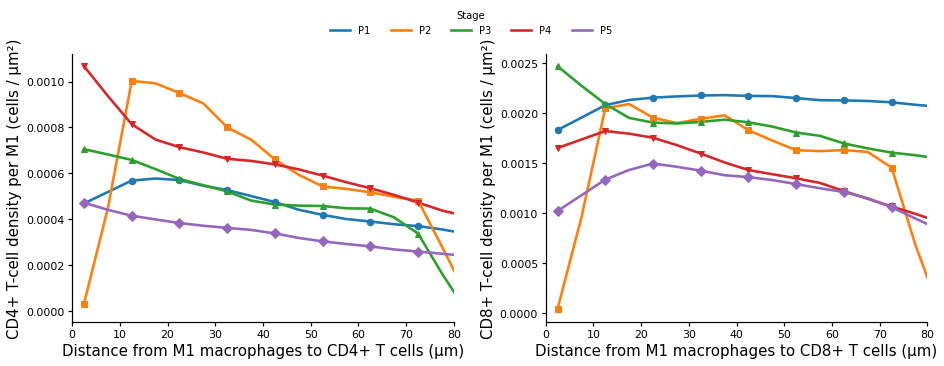


DONE.


In [10]:
# -*- coding: utf-8 -*-
# 从原始 annotated_cells_mixed.csv 开始：
# 计算 M1 周围 0–80 µm 的 ring-shell 径向密度（cells/µm^2），并用 LOWESS 平滑
# 输出：一张图，左右两个 panel
# 左：CD4；右：CD8
# 改进版：
# 1) 去掉 panel 上方的 CD4 / CD8 标注
# 2) 在各自横坐标中体现细胞类型
# 3) 图例为整张图顶部共用
# 4) 仅保留左/下坐标轴，JCC 风格
# 5) 自动保存 PNG / PDF

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from statsmodels.nonparametric.smoothers_lowess import lowess

# ====================== 参数区（只改这里） ======================
file_path = r"C:/Users/Li Chujia/Desktop/cell_annotationV2/annotated_cells_mixed.csv"

MAX_R = 80.0
BIN = 5.0
EPS = 1e-12

LOWESS_FRAC = 0.35
MARK_EVERY_BINS = 2

# ========= 保存参数 =========
OUT_DIR = r"C:/Users/Li Chujia/ipynb/typex"
OUT_BASENAME = "Fig3a_M1_radial_density_CD4_CD8_side_by_side"

SAVE_PNG = True
SAVE_PDF = True
DPI = 600

# 是否同时弹出图窗
SHOW_FIG = True

# ========= 版式参数 =========
FIG_W = 13.2
FIG_H = 5.4
WSPACE = 0.24
TOP_MARGIN = 0.83
BOTTOM_MARGIN = 0.14
LEFT_MARGIN = 0.08
RIGHT_MARGIN = 0.98

# ========= 字号与线条参数 =========
X_LABEL_SIZE = 15
Y_LABEL_SIZE = 15
X_TICK_SIZE  = 11
Y_TICK_SIZE  = 11
LEGEND_SIZE  = 10

AXIS_LW = 1.2
LINE_W = 2.6
MARKER_SIZE = 6.5

# ========= 总图例位置 =========
LEGEND_Y = 0.965
LEGEND_NCOL = 5

# 是否统一左右两个 panel 的 y 轴范围
SHARE_Y = False

# stage 映射：Txxx -> P1..P5
stage_labels = {"T005":"P1","T006":"P2","T001":"P3","T002":"P4","T004":"P5"}
stage_codes  = ["T005","T006","T001","T002","T004"]
stage_order  = ["P1","P2","P3","P4","P5"]

# 列名（按你文件）
COL_ROI  = "ROI"
COL_X    = "X_position"
COL_Y    = "Y_position"
COL_TYPE = "cell_type"

# cell_type 名称
M1_NAME  = "M1"
CD4_NAME = "CD4_T"
CD8_NAME = "CD8_T"

# ====== 可选：按你指定 ROI 白名单过滤（需要就取消注释）======
# roi_whitelist = {
#     "T001": {"001", "003", "007"},
#     "T002": {"021", "023"},
#     "T006": {"001", "003"},
#     "T004": {"008", "010"},
#     "T005": {"001", "003", "004"},
# }

# ====================== 颜色与点形状 ======================
COLOR_MAP = {
    "P1": "#1f77b4",
    "P2": "#ff7f0e",
    "P3": "#2ca02c",
    "P4": "#d62728",
    "P5": "#9467bd",
}
MARKER_MAP = {
    "P1": "o",
    "P2": "s",
    "P3": "^",
    "P4": "v",
    "P5": "D",
}

# ====================== 工具函数 ======================
def extract_stage(roi_str: str):
    if pd.isna(roi_str):
        return None
    m = re.search(r"(T\d{3})", str(roi_str))
    return m.group(1) if m else None

def extract_roi_num3(roi_str: str):
    if pd.isna(roi_str):
        return None
    s = str(roi_str)
    m = re.search(r"ROI\D*(\d{1,3})", s, flags=re.IGNORECASE)
    if m:
        return f"{int(m.group(1)):03d}"
    m2 = re.findall(r"(\d{1,3})", s)
    return f"{int(m2[-1]):03d}" if m2 else None

def annulus_area(r_in, r_out):
    return np.pi * (r_out**2 - r_in**2)

def lowess_smooth(x, y, frac=0.35):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    if len(x) < 5:
        return y
    return lowess(y, x, frac=frac, return_sorted=False)

def per_roi_radial_density(g_roi: pd.DataFrame, t_type: str, bins: np.ndarray, max_r: float):
    """
    单 ROI 内：
    对每个 M1 统计 t_type 在每个环带的数量 -> counts_sum
    count_mean_perM1 = counts_sum / n_M1
    density_perM1 = count_mean_perM1 / annulus_area
    """
    coords = g_roi[[COL_X, COL_Y]].to_numpy()
    types  = g_roi[COL_TYPE].to_numpy()

    m1 = coords[types == M1_NAME]
    t  = coords[types == t_type]

    if len(m1) == 0 or len(t) == 0:
        return None, None

    tree_t = cKDTree(t)
    n_bins = len(bins) - 1
    counts_sum = np.zeros(n_bins, dtype=float)

    for p in m1:
        idx = tree_t.query_ball_point(p, r=max_r)
        if not idx:
            continue
        d = np.sqrt(((t[idx] - p) ** 2).sum(axis=1))
        c, _ = np.histogram(d, bins=bins)
        counts_sum += c

    count_mean = counts_sum / len(m1)

    areas = np.array([annulus_area(bins[i], bins[i+1]) for i in range(n_bins)], dtype=float)
    density_mean = count_mean / (areas + EPS)

    return count_mean, density_mean

def set_jcc_style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(AXIS_LW)
    ax.spines["bottom"].set_linewidth(AXIS_LW)

    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")

    ax.tick_params(
        axis="x",
        which="both",
        direction="out",
        labelsize=X_TICK_SIZE,
        width=AXIS_LW,
        length=4
    )
    ax.tick_params(
        axis="y",
        which="both",
        direction="out",
        labelsize=Y_TICK_SIZE,
        width=AXIS_LW,
        length=4
    )

    ax.grid(False)

def load_data(file_path):
    df = None
    for enc in ["utf-8-sig", "gb18030", "gbk", "latin1", "utf-8"]:
        try:
            df = pd.read_csv(file_path, encoding=enc)
            print(f"Loaded with encoding: {enc}")
            break
        except Exception:
            pass

    if df is None:
        raise RuntimeError(f"无法读取：{file_path}")

    need = [COL_ROI, COL_X, COL_Y, COL_TYPE]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise KeyError(f"原始表缺少列：{missing}")

    df = df.dropna(subset=[COL_ROI, COL_X, COL_Y, COL_TYPE]).copy()
    df[COL_X] = pd.to_numeric(df[COL_X], errors="coerce")
    df[COL_Y] = pd.to_numeric(df[COL_Y], errors="coerce")
    df = df.dropna(subset=[COL_X, COL_Y]).copy()
    df[COL_TYPE] = df[COL_TYPE].astype(str)

    df["StageCode"] = df[COL_ROI].apply(extract_stage)
    df = df[df["StageCode"].isin(stage_codes)].copy()
    df["Stage"] = df["StageCode"].map(stage_labels)

    # ====== 可选白名单过滤 ======
    # df["ROI_num3"] = df[COL_ROI].apply(extract_roi_num3)
    # df = df[df.apply(lambda r: r["ROI_num3"] in roi_whitelist.get(r["StageCode"], set()), axis=1)].copy()

    print("\n▶ Stage counts:")
    print(df["Stage"].value_counts())
    print("\n▶ ROI list per stage (n):")
    print(df.groupby("Stage")[COL_ROI].nunique())

    return df

def build_stage_curve(df):
    bins = np.arange(0, MAX_R + BIN + 1e-9, BIN)
    bin_mid = (bins[:-1] + bins[1:]) / 2

    records = []
    for roi, g in df.groupby(COL_ROI):
        st = g["Stage"].iloc[0]

        for cell_label, t_type in [("CD4", CD4_NAME), ("CD8", CD8_NAME)]:
            count_mean, dens_mean = per_roi_radial_density(g, t_type, bins, MAX_R)
            if count_mean is None:
                continue

            for k, rmid in enumerate(bin_mid):
                records.append({
                    "Stage": st,
                    "ROI": roi,
                    "cell": cell_label,
                    "r_mid": float(rmid),
                    "density_perM1": float(dens_mean[k]),
                })

    radial = pd.DataFrame(records)
    if radial.empty:
        raise RuntimeError("radial 为空：检查是否存在 M1 与 CD4_T / CD8_T，或是否被白名单过滤掉。")

    stage_curve = radial.groupby(["Stage", "cell", "r_mid"]).agg(
        median_density=("density_perM1", "median"),
        n_ROI=("ROI", "nunique"),
    ).reset_index()

    stage_curve["Stage"] = pd.Categorical(stage_curve["Stage"], categories=stage_order, ordered=True)
    stage_curve = stage_curve.sort_values(["cell", "Stage", "r_mid"]).reset_index(drop=True)
    return stage_curve

def draw_one_panel(ax, stage_curve, cell="CD4",
                   x_label_text="Distance from M1 macrophages to CD4+ T cells (μm)",
                   y_label_text="CD4+ T-cell density per M1 (cells / μm²)"):
    sub = stage_curve[stage_curve["cell"] == cell]

    handles = []
    labels = []

    for st in stage_order:
        sst = sub[sub["Stage"] == st].sort_values("r_mid")
        if sst.empty:
            continue

        x = sst["r_mid"].to_numpy()
        y = sst["median_density"].to_numpy()
        y_s = lowess_smooth(x, y, frac=LOWESS_FRAC)

        color = COLOR_MAP[st]
        marker = MARKER_MAP[st]

        line, = ax.plot(
            x, y_s,
            color=color,
            linewidth=LINE_W,
            label=st,
            zorder=2
        )

        idx_mark = np.arange(0, len(x), MARK_EVERY_BINS)
        ax.plot(
            x[idx_mark], y_s[idx_mark],
            linestyle="None",
            marker=marker,
            markersize=MARKER_SIZE,
            markerfacecolor=color,
            markeredgecolor=color,
            zorder=3
        )

        handles.append(line)
        labels.append(st)

    ax.set_xlabel(x_label_text, fontsize=X_LABEL_SIZE)
    ax.set_ylabel(y_label_text, fontsize=Y_LABEL_SIZE)

    set_jcc_style_axes(ax)
    return handles, labels

def save_figure(fig, out_dir, out_basename, save_png=True, save_pdf=True, dpi=600):
    os.makedirs(out_dir, exist_ok=True)
    saved_files = []

    if save_png:
        png_path = os.path.join(out_dir, f"{out_basename}.png")
        fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        saved_files.append(png_path)

    if save_pdf:
        pdf_path = os.path.join(out_dir, f"{out_basename}.pdf")
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
        saved_files.append(pdf_path)

    return saved_files

def plot_side_by_side(stage_curve):
    fig, axes = plt.subplots(
        1, 2,
        figsize=(FIG_W, FIG_H),
        sharey=SHARE_Y
    )

    handles_left, labels_left = draw_one_panel(
        axes[0],
        stage_curve,
        cell="CD4",
        x_label_text="Distance from M1 macrophages to CD4+ T cells (μm)",
        y_label_text="CD4+ T-cell density per M1 (cells / μm²)"
    )

    draw_one_panel(
        axes[1],
        stage_curve,
        cell="CD8",
        x_label_text="Distance from M1 macrophages to CD8+ T cells (μm)",
        y_label_text="CD8+ T-cell density per M1 (cells / μm²)"
    )

    for ax in axes:
        ax.set_xlim(0, MAX_R)

    fig.legend(
        handles_left, labels_left,
        title="Stage",
        frameon=False,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
        loc="upper center",
        bbox_to_anchor=(0.5, LEGEND_Y),
        ncol=LEGEND_NCOL
    )

    plt.subplots_adjust(
        left=LEFT_MARGIN,
        right=RIGHT_MARGIN,
        bottom=BOTTOM_MARGIN,
        top=TOP_MARGIN,
        wspace=WSPACE
    )

    saved_files = save_figure(
        fig,
        out_dir=OUT_DIR,
        out_basename=OUT_BASENAME,
        save_png=SAVE_PNG,
        save_pdf=SAVE_PDF,
        dpi=DPI
    )

    print("\nSaved files:")
    for f in saved_files:
        print(f)

    if SHOW_FIG:
        plt.show()
    else:
        plt.close(fig)

# ====================== 主程序 ======================
df = load_data(file_path)
stage_curve = build_stage_curve(df)
plot_side_by_side(stage_curve)

print("\nDONE.")